In [6]:
# Step 0. Import libraries, custom modules and logging
# Basics ---------------------------------------------------------------
import logging
import joblib
# Data -----------------------------------------------------------------
import pandas as pd
import numpy as np
# Graphics -------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
# Machine learning -----------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (OneHotEncoder,
                                   LabelEncoder,
                                   MinMaxScaler)
from sklearn.metrics import (accuracy_score,
                             f1_score,
                             classification_report,
                             ConfusionMatrixDisplay,
                             RocCurveDisplay,
                             DetCurveDisplay)
from sklearn.tree import plot_tree
# Logging initialization -----------------------------------------------
logger = logging.getLogger()
logger.setLevel(logging.INFO)

In [7]:
# Step 1. Load data and wrangle ----------------------------------
# 1.1 Read from source and get basic info
url = ('https://gist.githubusercontent.com/teamtom/' + 
       '1af7b484954b2d4b7e981ea3e7a27f24/raw/' + 
       '114fb69dce56b4462a9c3a417e7402330616ad4f/' + 
       'titanic_full.csv')
df_raw = pd.read_csv(url)
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  746 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB


In [8]:
df_raw_2 = pd.read_csv("df_raw_titanic.csv", sep=",", )
df_raw_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  746 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB


In [9]:
df_raw.sample(10, random_state= 2024)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
1077,3,0,Franklin Mr. Charles Charles Fardon,male,NaN,0,0,SOTON/O.Q. 3101314,7.2500,NaN,S,NaN,NaN,NaN
1177,3,0,Lindell Mrs. Edvard Bengtsson Elin Gerda Persson,female,30.0,1,0,349910,15.5500,NaN,S,A,NaN,NaN
1164,1,1,Beckwith Mrs. Richard Leonard Sallie Monypeny,female,47.0,1,1,11751,52.5542,D35,S,5,NaN,New York NY
370,3,1,Murphy Miss. Katherine Kate,female,NaN,1,0,367230,15.5000,NaN,Q,16,NaN,NaN
971,3,1,Hakkarainen Mrs. Pekka Pietari Elin Matilda Dolck,female,24.0,1,0,STON/O2. 3101279,15.8500,NaN,S,15,NaN,NaN
342,3,0,Danbom Mr. Ernst Gilbert,male,34.0,1,1,347080,14.4000,NaN,S,NaN,197.0,Stanton IA
459,1,0,Hipkins Mr. William Edward,male,55.0,0,0,680,50.0000,C39,S,NaN,NaN,London / Birmingham
365,3,0,Andersson Miss. Ellis Anna Maria,female,2.0,4,2,347082,31.2750,NaN,S,NaN,NaN,Sweden Winnipeg MN
69,3,0,Wiklund Mr. Karl Johan,male,21.0,1,0,3101266,6.4958,NaN,S,NaN,NaN,NaN
232,1,1,Harper Mrs. Henry Sleeper Myna Haxtun,female,49.0,1,0,PC 17572,76.7292,D33,C,3,NaN,New York NY


## Dictionary

| Variable	| Description	| Details |
| ----------|---------------|---------|
| survival |	Survival	| 0 = No; 1 = Yes |
| pclass	| Passenger Class	| 1 = 1st; 2 = 2nd; 3 = 3rd |
| name	| First and Last Name | |	 
| sex	| Sex |	| 
| age	| Age | |	 
| sibsp |	Number of Siblings/Spouses Aboard	 | |
| parch |	Number of Parents/Children Aboard	 | |
| ticket |	Ticket Number	 | |
| fare |	Passenger Fare	 | |
| cabin |	Cabin	 | |
| embarked |	Port of Embarkation | 	C = Cherbourg; Q = Queenstown; S = Southampton |
| boat	|Lifeboat | |
| body | Body Identification Number | |
| home.dest | Home/Destination | |

In [10]:
df_interim = (
    df_raw
    .copy()
    .set_axis(
        df_raw.columns.str.replace(' ','_')
        .str.replace(r'\W','',regex=True)
        .str.lower()
        .str.slice(0,40), axis=1
    )
    .drop(['ticket','boat','body','homedest','cabin','name'], axis=1)
    .drop_duplicates()
    .assign(
        absent_age = df_raw['age'].apply(lambda x: 'yes' if pd.isna(x) else 'no'),
        survived = df_raw['survived'].map({1:'Survived', 0:'Perished'})
    )
    .rename(columns={'survived':'target'})
    .astype({'target':'category', 
             'pclass': 'category', 
             'sex': 'category',
             'embarked':'category',
             'absent_age': 'category'})
)


In [11]:
# 2.2 Create the final dataset with the target in front
df = (
    df_interim
    .copy()
    .reindex(
        columns=(
            ['target'] + 
            [c for c in df_interim.columns.to_list() if c not in ['target']]
        )
    )
)

In [12]:
df.head()

,target,pclass,sex,age,sibsp,parch,fare,embarked,absent_age
0,Perished,3,female,NaN,0,0,7.8792,Q,yes
1,Perished,1,male,NaN,0,0,52.0000,S,yes
2,Perished,3,male,27.0,1,0,14.4542,C,no
3,Survived,3,male,25.0,0,0,7.7958,S,no
4,Perished,3,male,34.5,0,0,7.8292,Q,no


In [13]:
# Step 3. Perform EDA
# 3.1 Split the dataset
df_train, df_test = train_test_split(df, 
                                     random_state=2024, 
                                     test_size=0.20, 
                                     stratify=df['target'])
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 540 to 744
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   target      891 non-null    category
 1   pclass      891 non-null    category
 2   sex         891 non-null    category
 3   age         779 non-null    float64 
 4   sibsp       891 non-null    int64   
 5   parch       891 non-null    int64   
 6   fare        890 non-null    float64 
 7   embarked    889 non-null    category
 8   absent_age  891 non-null    category
dtypes: category(5), float64(2), int64(2)
memory usage: 39.8 KB


In [14]:
# Step 3.2
display(df_train.describe(include= 'number').T)
display(df_train.describe(include= 'category').T)

,count,mean,std,min,25%,50%,75%,max
age,779.0,29.933787,15.040307,0.17,20.25,28.0,39.0000,80.0000
sibsp,891.0,0.537598,0.992947,0.00,0.00,0.0,1.0000,8.0000
parch,891.0,0.436588,0.895160,0.00,0.00,0.0,1.0000,9.0000
fare,890.0,37.414035,58.028996,0.00,8.05,15.8,34.5844,512.3292


,count,unique,top,freq
target,891,2,Perished,517
pclass,891,3,3,458
sex,891,2,male,555
embarked,889,3,S,622
absent_age,891,2,no,779


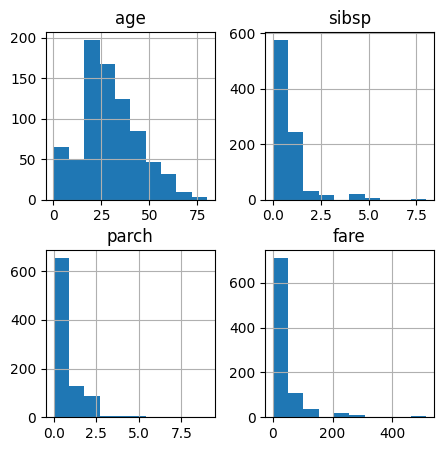

In [15]:
# Step 3.3 Univaried Analysis
df_train.hist(figsize=(5, 5))
plt.show()

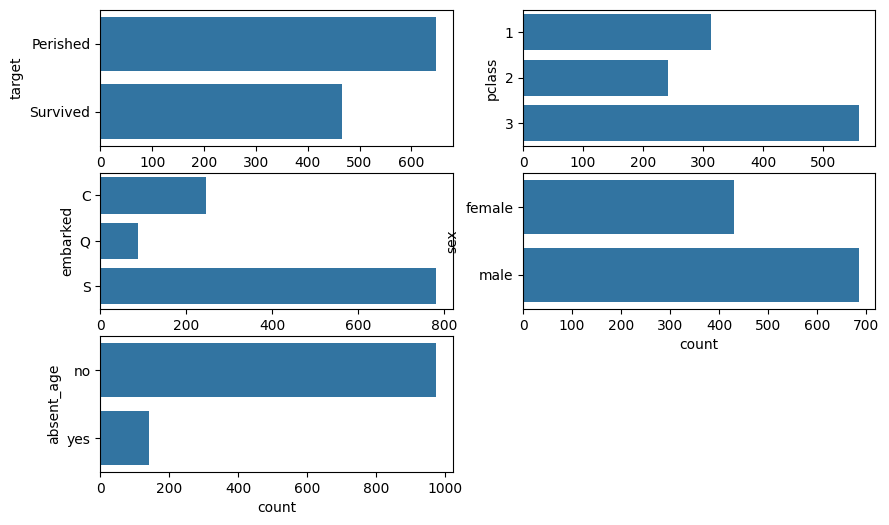

In [16]:
# Step 3.4 Univariate Analysis
fig, ax = plt.subplots(3, 2,  figsize= (10, 6))
sns.countplot(data= df, y= 'target', ax= ax[0, 0])
sns.countplot(data= df, y= 'pclass', ax= ax[0, 1])
sns.countplot(data= df, y= 'embarked', ax= ax[1, 0])
sns.countplot(data= df, y= 'sex', ax= ax[1, 1])
sns.countplot(data= df, y= 'absent_age', ax= ax[2, 0])

# Eliminate fig ax[2,1], because we have 5 figs
fig.delaxes(ax[2, 1])
plt.show()

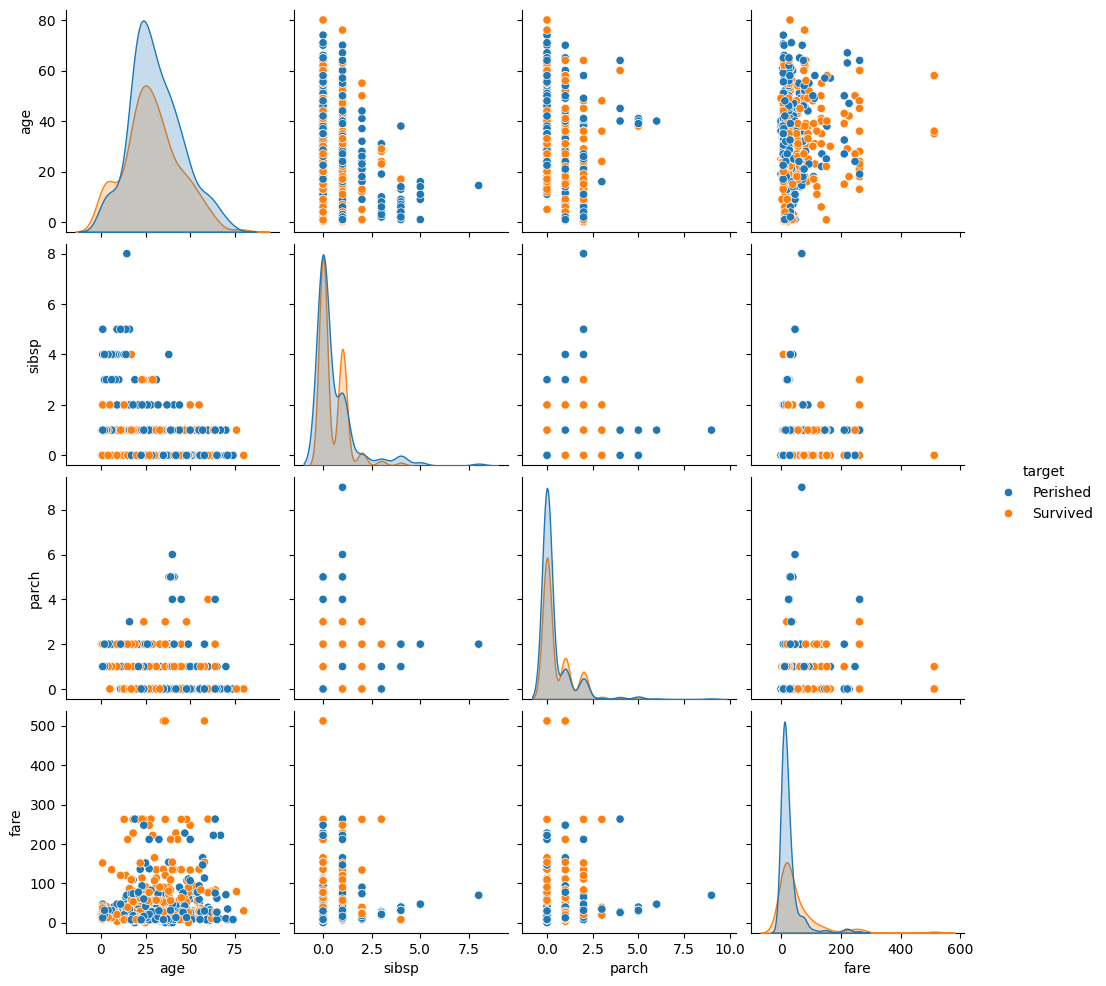

In [17]:
# Step 3.5 Bivariate Analysis

sns.pairplot(data= df_train, hue= 'target')
plt.show()

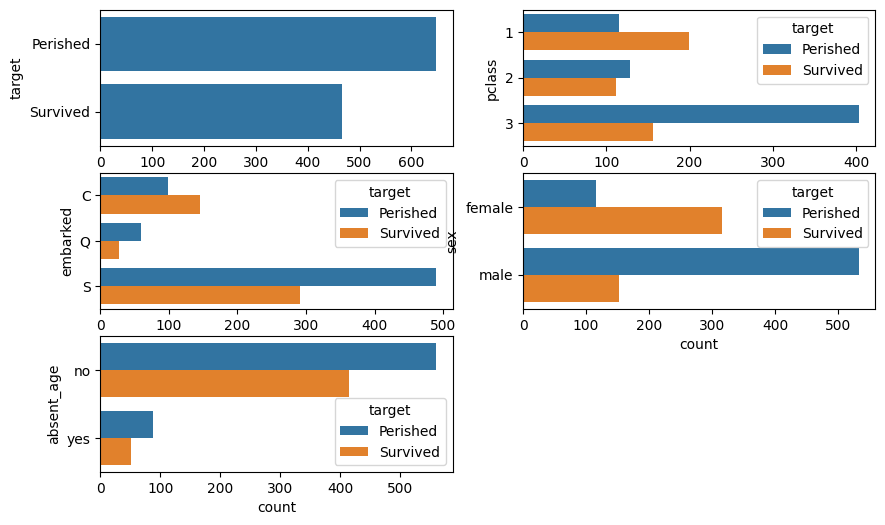

In [18]:
# Step 3.6 Bivariate Analysis for category
fig, ax = plt.subplots(3, 2,  figsize= (10, 6))
sns.countplot(data= df, y= 'target', ax= ax[0, 0])
sns.countplot(data= df, y= 'pclass', hue= 'target', ax= ax[0, 1])
sns.countplot(data= df, y= 'embarked', hue= 'target', ax= ax[1, 0])
sns.countplot(data= df, y= 'sex', hue= 'target', ax= ax[1, 1])
sns.countplot(data= df, y= 'absent_age', hue= 'target', ax= ax[2, 0])

# Eliminate fig ax[2,1], because we have 5 figs
fig.delaxes(ax[2, 1])
plt.show()

- **embarked:** maybe a good predictor variable due to the growth reversal
- **agsent_age:** Does not seem to be a good predictor variable
- **pclass:** should be a good predictor variable, because the blue bar is slightly larger than the orange one in 1 and 2 vs. in case 3 it is the other way around
- **sex:** is a possible good predictor variable due to the proportion reversal in both cases

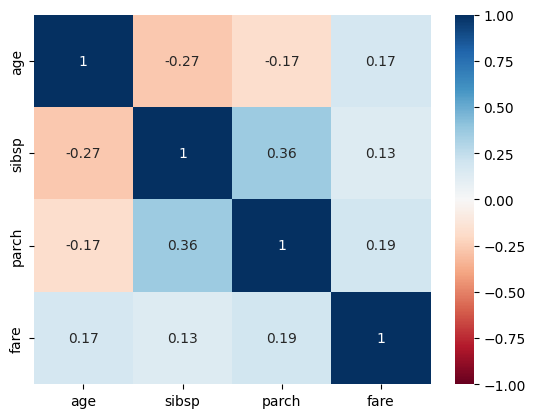

In [19]:
# Step 3.7 Correlation Analysis
sns.heatmap(df_train.select_dtypes('number').corr(), vmin= -1, vmax= 1, annot= True, cmap='RdBu')
plt.show()

There is no correlation between the variables

In [20]:
# Step 4. Create a machine learning model
# 4.1 Split features and reponse
X_train = df_train.drop('target', axis=1).reset_index(drop=True)
y_train = df_train['target'].reset_index(drop=True)
X_test = df_test.drop('target', axis=1).reset_index(drop=True)
y_test = df_test['target'].reset_index(drop=True)

In [21]:
y_train.head()

0    Perished
1    Perished
2    Survived
3    Perished
4    Perished
Name: target, dtype: category
Categories (2, object): ['Perished', 'Survived']

In [22]:
X_train.head()

,pclass,sex,age,sibsp,parch,fare,embarked,absent_age
0,3,female,28.0,0,0,7.8958,S,no
1,1,male,51.0,0,1,61.3792,C,no
2,1,female,51.0,1,0,77.9583,S,no
3,1,male,46.0,0,0,79.2000,C,no
4,3,male,NaN,0,0,14.4583,C,yes


In [23]:
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

In [24]:
cat_cols = X_train.select_dtypes('category').columns
num_cols = X_train.select_dtypes('number').columns

In [25]:
cat_proc = Pipeline([
    ('imputer', SimpleImputer(strategy= 'most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown= 'ignore'))
])

num_proc = Pipeline([
    ('imputer', SimpleImputer(strategy= 'mean')),
    ('scaler',  MinMaxScaler())
])

procesor = ColumnTransformer(transformers= [
    ('cat', cat_proc, cat_cols),
    ('num', num_proc, num_cols)
])

In [26]:
procesor

,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None


In [27]:
clf_tree = Pipeline([
    ('proc', procesor),
    ('tree', DecisionTreeClassifier(class_weight= 'balanced')) # balanced
])

In [28]:
clf_tree.fit(X_train, y_train_enc)

,steps,"[('proc', ...), ('tree', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [29]:
# Prediction
y_pred = clf_tree.predict(X_test)

In [30]:
print(f"Accuracy: {accuracy_score(y_test_enc, y_pred)}")

Accuracy: 0.7130044843049327


In [31]:
print(f"f1_score: {f1_score(y_test_enc, y_pred)}")

f1_score: 0.68


In [32]:
print(classification_report(y_test_enc, y_pred, target_names= label_encoder.classes_))

              precision    recall  f1-score   support

    Perished       0.78      0.70      0.74       130
    Survived       0.64      0.73      0.68        93

    accuracy                           0.71       223
   macro avg       0.71      0.72      0.71       223
weighted avg       0.72      0.71      0.71       223



Existe un desbalance en nuestra data, debido a que existe un mayor número mayor de Perished

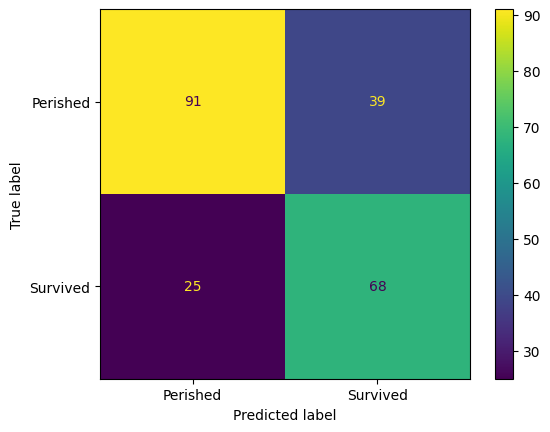

In [33]:
# Consided the firts element of .from_predictions is the data test, the second data is the prediction
ConfusionMatrixDisplay.from_predictions(y_test_enc, y_pred, display_labels= label_encoder.classes_)
plt.show()

**Desbalancced**
- Sum raw[0] = 130
- Sum raw[1] = 93
There are big difference = desbalanced

**Others:**
- Raws is predict data
- Columns is test data
- [0, 0] and [1, 1] = diagonal is affirmative
- [0 , 0] is True Positive **TP**
- [1, 1] is True Negative **TN**
- [0, 1] is False Negative **FN**
- [1, 0] is False Positive **FP**

**Preccision** = TP / (TP + FP) # Read Column
- p(y=1|ŷ=1)
**recall** = TP / (TP+FN) # Read Raw
- p(ŷ=1|y=1)

**f1_score** = 2((precision * recall) / (preccision + recall))

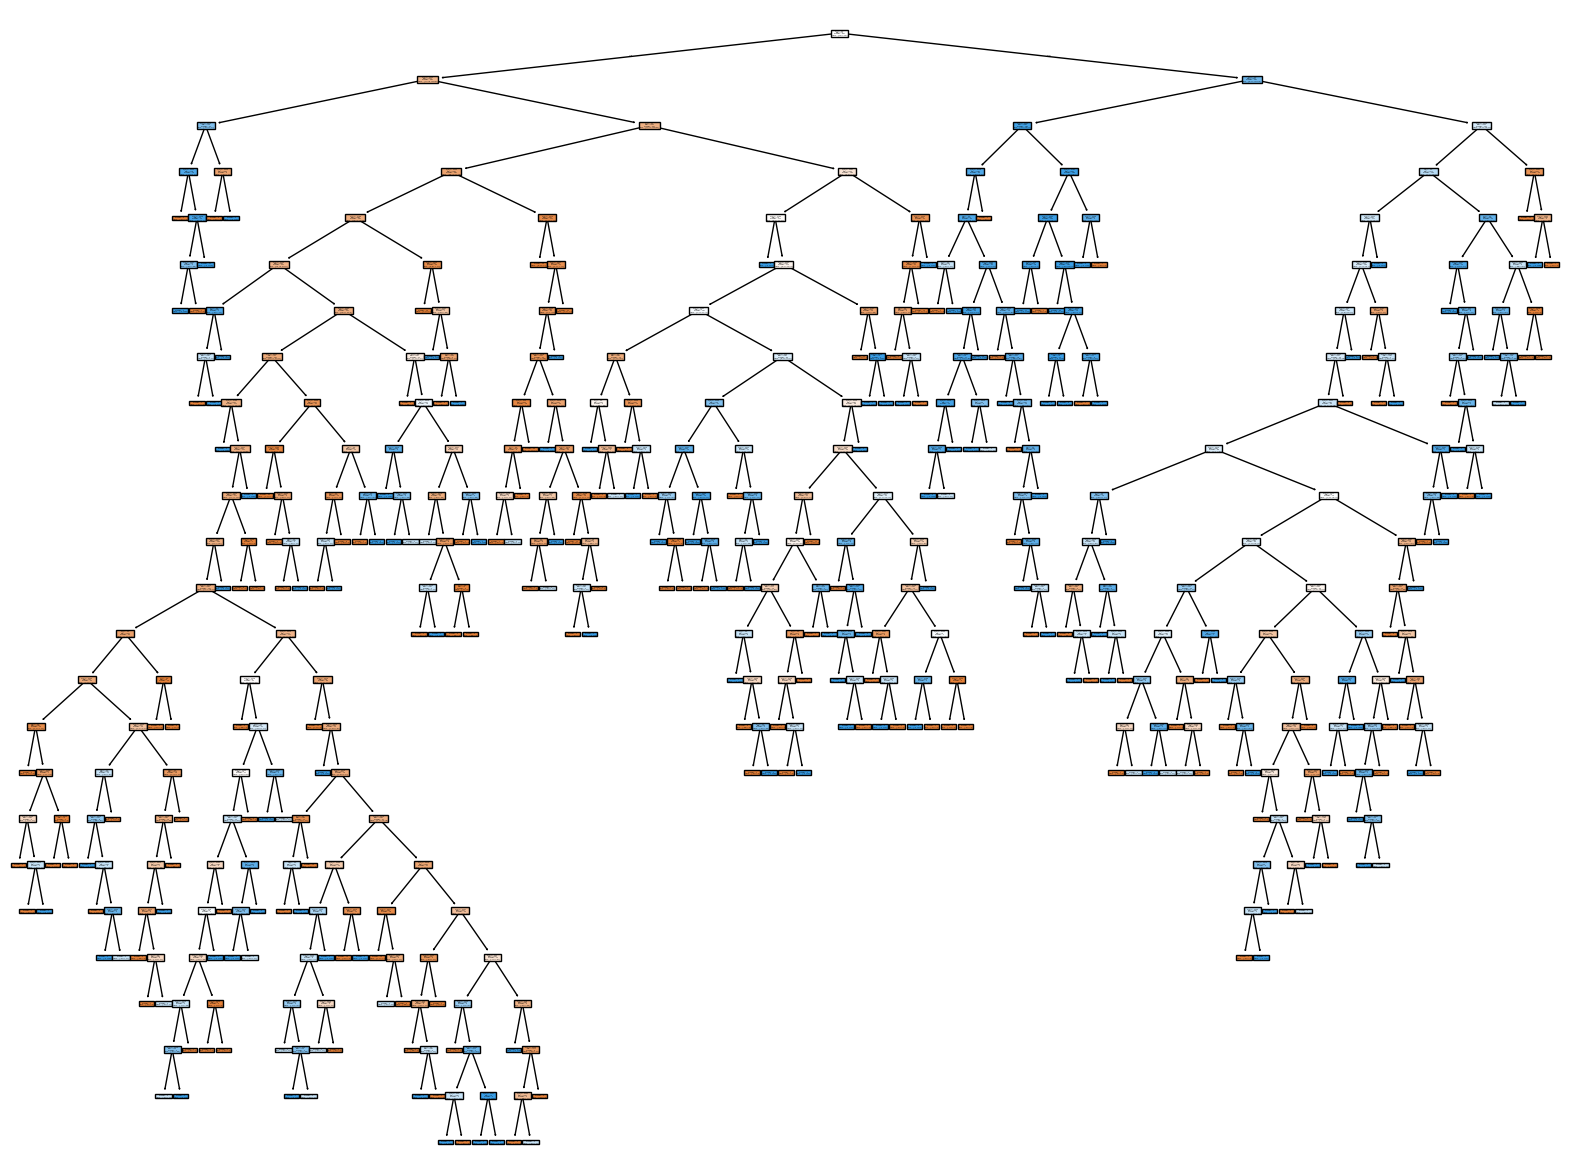

In [34]:
# Tree
my_tree = clf_tree.named_steps['tree']
plt.figure(figsize= (20,15))
plot_tree(my_tree, filled= True)
plt.show()